<a href="https://colab.research.google.com/github/YM1587/ALX-PYTHON/blob/main/deepface_face_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deepface

In [ ]:
pip install --ignore-installed blinker

In [ ]:
pip install deepface

In [ ]:
pip install tf-keras

In [ ]:
from deepface import DeepFace

In [ ]:
import deepface
print(f'DeepFace version: {deepface.__version__}')
print('Import successful!')

In [ ]:
models = [
  "VGG-Face",
  "Facenet",
  "Facenet512",
  "OpenFace",
  "DeepFace",
  "DeepID",
  "ArcFace",
  "Dlib",
  "SFace",
  "GhostFaceNet",
]

print("Available face recognition models:")
for model in models:
    print(f"- {model}")

# Also listing available backends for face detection
detectors = ["opencv", "retinaface", "mtcnn", "ssd", "dlib", "mediapipe", "yolov8", "pixellib", "centerface"]
print("\nAvailable face detector backends:")
for detector in detectors:
    print(f"- {detector}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

def find_folder(name, search_path='/content/drive/MyDrive'):
    for root, dirs, files in os.walk(search_path):
        if name.lower() in [d.lower() for d in dirs]:
            # Returns the full path of the first matching folder name
            for d in dirs:
                if d.lower() == name.lower():
                    return os.path.join(root, d)
    return None

# Searching for your folders
folder_names = ["Trump", "Prophet lovy", "Christie"]
folders = {}

print("Searching for folders in Google Drive...")
for name in folder_names:
    found_path = find_folder(name)
    if found_path:
        folders[name] = found_path
        files = [f for f in os.listdir(found_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"[SUCCESS] Found '{name}' at: {found_path} ({len(files)} images)")
    else:
        print(f"[ERROR] Could not find a folder named '{name}' in Drive.")

# These paths will be used in subsequent face recognition steps.

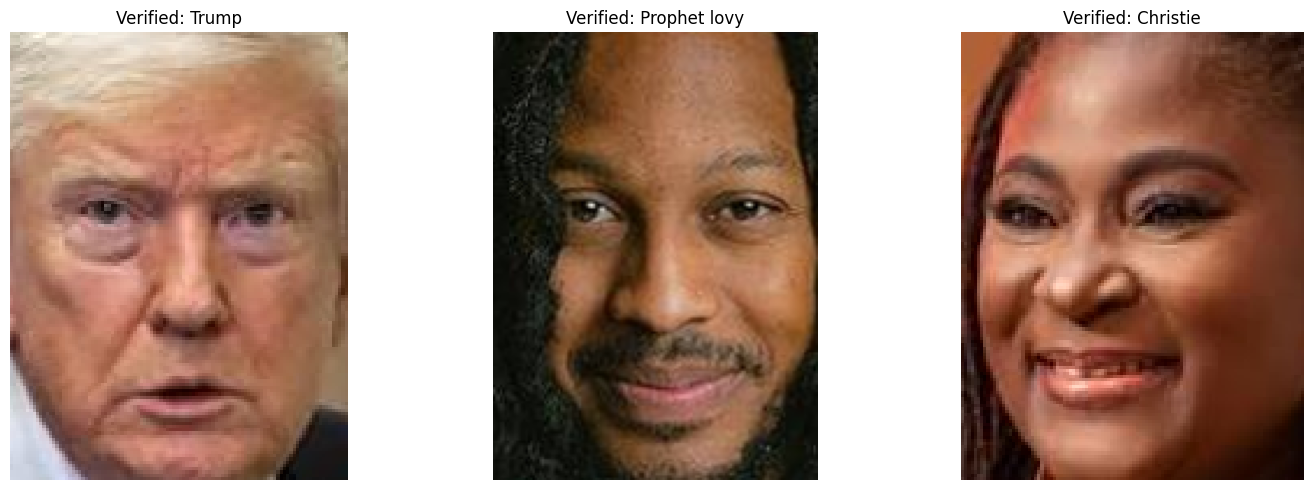

In [ ]:
import os
import matplotlib.pyplot as plt

# 1. Final Environment Setup
os.environ["TF_USE_LEGACY_KERAS"] = "1"
from deepface import DeepFace

# 2. Re-verify folders (ensuring paths are current)
folder_names = ["Trump", "Prophet lovy", "Christie"]
active_folders = {}
def find_path(name):
    for root, dirs, _ in os.walk('/content/drive/MyDrive'):
        for d in dirs:
            if d.lower() == name.lower():
                return os.path.join(root, d)
    return None

for name in folder_names:
    p = find_path(name)
    if p: active_folders[name] = p

# 3. Process and Display one face from each folder
fig, axes = plt.subplots(1, len(active_folders), figsize=(15, 5))
if len(active_folders) == 1: axes = [axes]

for i, (name, path) in enumerate(active_folders.items()):
    valid_imgs = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not valid_imgs:
        print(f"No images in {name}")
        continue

    img_path = os.path.join(path, valid_imgs[0])
    try:
        # Using MTCNN for high accuracy verification
        results = DeepFace.extract_faces(img_path=img_path, detector_backend='mtcnn', enforce_detection=False)
        if results:
            axes[i].imshow(results[0]['face'])
            axes[i].set_title(f"Verified: {name}")
            axes[i].axis('off')
    except Exception as e:
        print(f"Could not process {name}: {e}")

plt.tight_layout()
plt.show()

In [ ]:
img1_path = os.path.join(active_folders['Trump'], os.listdir(active_folders['Trump'])[0])
img2_path = os.path.join(active_folders['Prophet lovy'], os.listdir(active_folders['Prophet lovy'])[0])

print(f"Comparing:\n1. {img1_path}\n2. {img2_path}\n")

try:
    verification = DeepFace.verify(
        img1_path = img1_path,
        img2_path = img2_path,
        model_name = "VGG-Face",
        detector_backend = "mtcnn"
    )

    display(verification)

    if verification["verified"]:
        print("\nResult: The images belong to the same person.")
    else:
        print("\nResult: The images belong to different people.")
except Exception as e:
    print(f"Verification failed: {e}")

Comparing:
1. /content/drive/MyDrive/Trump/images.jpeg
2. /content/drive/MyDrive/Prophet lovy/image1.jpeg

26-07-13 08:06:17 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:02<00:00, 211MB/s]


{'verified': False,
 'distance': 0.949743,
 'threshold': 0.68,
 'confidence': 0.83,
 'model': 'VGG-Face',
 'detector_backend': 'mtcnn',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 218,
   'y': 37,
   'w': 104,
   'h': 138,
   'left_eye': (295, 94),
   'right_eye': (249, 92)},
  'img2': {'x': 137,
   'y': 95,
   'w': 140,
   'h': 193,
   'left_eye': (243, 169),
   'right_eye': (177, 170)}},
 'time': 5.02}


Result: The images belong to different people.


In [ ]:
compare_models = ["Facenet", "ArcFace", "SFace"]
results_summary = []

print(f"Comparing images using multiple models...\n")

for model in compare_models:
    print(f"--- Running verification with: {model} ---")
    try:
        res = DeepFace.verify(
            img1_path = img1_path,
            img2_path = img2_path,
            model_name = model,
            detector_backend = "mtcnn",
            enforce_detection = False
        )
        results_summary.append({
            "Model": model,
            "Verified": res["verified"],
            "Distance": round(res["distance"], 4),
            "Threshold": res["threshold"]
        })
    except Exception as e:
        print(f"Error with model {model}: {e}")

import pandas as pd
df_results = pd.DataFrame(results_summary)
display(df_results)

Comparing images using multiple models...

--- Running verification with: Facenet ---
26-07-13 08:07:05 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:01<00:00, 78.5MB/s]


--- Running verification with: ArcFace ---
26-07-13 08:07:08 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:00<00:00, 146MB/s]


--- Running verification with: SFace ---
26-07-13 08:07:10 - 🔗 face_recognition_sface_2021dec.onnx will be downloaded from https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx to /root/.deepface/weights/face_recognition_sface_2021dec.onnx...


Downloading...
From: https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx
To: /root/.deepface/weights/face_recognition_sface_2021dec.onnx
100%|██████████| 38.7M/38.7M [00:00<00:00, 55.6MB/s]


,Model,Verified,Distance,Threshold
0,Facenet,False,0.8934,0.400
1,ArcFace,False,0.9564,0.680
2,SFace,False,1.1086,0.593


In [ ]:
import os

# Select two different images from the Trump folder
trump_imgs = [f for f in os.listdir(active_folders['Trump']) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(trump_imgs) >= 2:
    same_person_img1 = os.path.join(active_folders['Trump'], trump_imgs[0])
    same_person_img2 = os.path.join(active_folders['Trump'], trump_imgs[1])

    print(f"Testing Same Person Verification (Trump):\n1. {same_person_img1}\n2. {same_person_img2}\n")

    same_person_results = []
    for model in ["VGG-Face", "Facenet", "ArcFace"]:
        try:
            res = DeepFace.verify(
                img1_path = same_person_img1,
                img2_path = same_person_img2,
                model_name = model,
                detector_backend = "mtcnn",
                enforce_detection = False
            )
            same_person_results.append({
                "Model": model,
                "Verified": res["verified"],
                "Distance": round(res["distance"], 4),
                "Threshold": res["threshold"]
            })
        except Exception as e:
            print(f"Error with {model}: {e}")

    df_same = pd.DataFrame(same_person_results)
    display(df_same)
else:
    print("Not enough images in the Trump folder to perform this test.")

Testing Same Person Verification (Trump):
1. /content/drive/MyDrive/Trump/images.jpeg
2. /content/drive/MyDrive/Trump/images (1).jpeg



,Model,Verified,Distance,Threshold
0,VGG-Face,True,0.4336,0.68
1,Facenet,True,0.2480,0.40
2,ArcFace,True,0.3938,0.68


In [ ]:
import os

# Defining the specific paths based on the filenames seen in the Trump folder
img_1970 = os.path.join(active_folders['Trump'], 'trump 1970.jpeg')
img_1990 = os.path.join(active_folders['Trump'], 'trump 1990.jpeg')

print(f"Comparing Historical Images:\n1. {img_1970}\n2. {img_1990}\n")

age_gap_results = []

# We'll use the most robust models for this aging test
for model in ["VGG-Face", "Facenet", "ArcFace"]:
    print(f"--- Testing Age Gap with: {model} ---")
    try:
        res = DeepFace.verify(
            img1_path = img_1970,
            img2_path = img_1990,
            model_name = model,
            detector_backend = "mtcnn",
            enforce_detection = False
        )
        age_gap_results.append({
            "Model": model,
            "Verified": res["verified"],
            "Distance": round(res["distance"], 4),
            "Threshold": res["threshold"]
        })
    except Exception as e:
        print(f"Error with {model}: {e}")

df_age_gap = pd.DataFrame(age_gap_results)
display(df_age_gap)

Comparing Historical Images:
1. /content/drive/MyDrive/Trump/trump 1970.jpeg
2. /content/drive/MyDrive/Trump/trump 1990.jpeg

--- Testing Age Gap with: VGG-Face ---
--- Testing Age Gap with: Facenet ---
--- Testing Age Gap with: ArcFace ---


,Model,Verified,Distance,Threshold
0,VGG-Face,False,0.8034,0.68
1,Facenet,False,0.7296,0.40
2,ArcFace,False,0.8014,0.68


In [ ]:
print(f"Comparing Historical Images with SFace:\n1. {img_1970}\n2. {img_1990}\n")

try:
    res_sface = DeepFace.verify(
        img1_path = img_1970,
        img2_path = img_1990,
        model_name = "SFace",
        detector_backend = "mtcnn",
        enforce_detection = False
    )

    sface_result = {
        "Model": "SFace",
        "Verified": res_sface["verified"],
        "Distance": round(res_sface["distance"], 4),
        "Threshold": res_sface["threshold"]
    }

    display(pd.DataFrame([sface_result]))

    if res_sface["verified"]:
        print("\nSFace Result: Match detected!")
    else:
        print("\nSFace Result: No match detected (likely due to the 20-year age gap).")

except Exception as e:
    print(f"Error with SFace: {e}")

Comparing Historical Images with SFace:
1. /content/drive/MyDrive/Trump/trump 1970.jpeg
2. /content/drive/MyDrive/Trump/trump 1990.jpeg



,Model,Verified,Distance,Threshold
0,SFace,True,0.5628,0.593



SFace Result: Match detected!


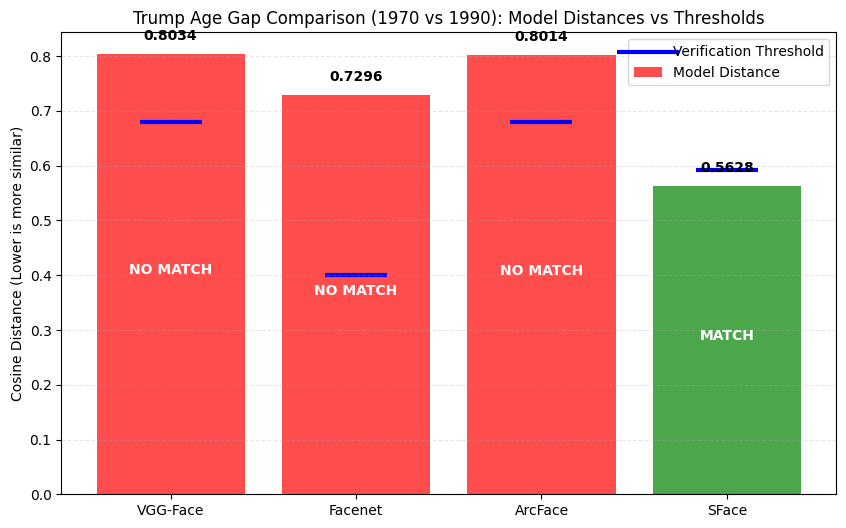

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combine results from previous tests for the 1970 vs 1990 comparison
plot_data = age_gap_results.copy()
plot_data.append(sface_result)
df_plot = pd.DataFrame(plot_data)

# Create the visualization
plt.figure(figsize=(10, 6))
x = np.arange(len(df_plot['Model']))

# Plotting Distances
bars = plt.bar(x, df_plot['Distance'], color=['red' if not v else 'green' for v in df_plot['Verified']], alpha=0.7, label='Model Distance')

# Plotting Thresholds as points or lines
plt.scatter(x, df_plot['Threshold'], color='blue', marker='_', s=2000, linewidth=3, label='Verification Threshold')

# Formatting
plt.xticks(x, df_plot['Model'])
plt.ylabel('Cosine Distance (Lower is more similar)')
plt.title('Trump Age Gap Comparison (1970 vs 1990): Model Distances vs Thresholds')
plt.legend()

# Adding text labels for clarity
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval}", ha='center', va='bottom', fontweight='bold')
    status = "MATCH" if df_plot['Verified'][i] else "NO MATCH"
    plt.text(bar.get_x() + bar.get_width()/2, yval / 2, status, ha='center', color='white', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [ ]:
import os
from deepface import DeepFace
import pandas as pd

# Define paths
img_1970 = os.path.join(active_folders['Trump'], 'trump 1970.jpeg')
# Using the first image in the folder as the 'recent' representative
img_recent = os.path.join(active_folders['Trump'], 'images.jpeg')

print(f"Comparing 1970 photo with a recent photo:\n1. {img_1970}\n2. {img_recent}\n")

try:
    # Using SFace and MTCNN as established in previous successful tests
    res_recent = DeepFace.verify(
        img1_path = img_1970,
        img2_path = img_recent,
        model_name = "SFace",
        detector_backend = "mtcnn",
        enforce_detection = False
    )

    recent_comparison = {
        "Model": "SFace",
        "Verified": res_recent["verified"],
        "Distance": round(res_recent["distance"], 4),
        "Threshold": res_recent["threshold"]
    }

    display(pd.DataFrame([recent_comparison]))

    if res_recent["verified"]:
        print(f"\nResult: Success! SFace matched the 1970 photo to the recent image (Distance: {recent_comparison['Distance']})")
    else:
        print(f"\nResult: No match. The age gap between 1970 and the recent photo (Distance: {recent_comparison['Distance']}) exceeded the threshold.")

except Exception as e:
    print(f"Error during verification: {e}")

Comparing 1970 photo with a recent photo:
1. /content/drive/MyDrive/Trump/trump 1970.jpeg
2. /content/drive/MyDrive/Trump/images.jpeg



,Model,Verified,Distance,Threshold
0,SFace,False,1.0236,0.593



Result: No match. The age gap between 1970 and the recent photo (Distance: 1.0236) exceeded the threshold.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from deepface import DeepFace

# Define reference image
ref_img_name = 'images.jpeg'
ref_img_path = os.path.join(active_folders['Trump'], ref_img_name)

# Get list of all other images in the folder
all_imgs = [f for f in os.listdir(active_folders['Trump']) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and f != ref_img_name]

batch_results = []

print(f"Comparing all images in folder against reference: {ref_img_name}\n")

for img_name in all_imgs:
    target_path = os.path.join(active_folders['Trump'], img_name)
    try:
        # Using SFace as the primary model
        res = DeepFace.verify(
            img1_path = ref_img_path,
            img2_path = target_path,
            model_name = "SFace",
            detector_backend = "mtcnn",
            enforce_detection = False
        )
        batch_results.append({
            "Filename": img_name,
            "Distance": round(res["distance"], 4),
            "Verified": res["verified"],
            "Threshold": res["threshold"]
        })
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

# Create DataFrame and sort by distance
df_batch = pd.DataFrame(batch_results).sort_values(by="Distance")
display(df_batch)

Comparing all images in folder against reference: images.jpeg



,Filename,Distance,Verified,Threshold
1,images (2).jpeg,0.0000,True,0.593
8,images (9).jpeg,0.3906,True,0.593
10,images (11).jpeg,0.4394,True,0.593
6,images (7).jpeg,0.4688,True,0.593
17,images (17).jpeg,0.4958,True,0.593
15,images (15).jpeg,0.5230,True,0.593
14,images (14).jpeg,0.5230,True,0.593
11,images (12).jpeg,0.5242,True,0.593
7,images (8).jpeg,0.6097,False,0.593
5,images (6).jpeg,0.6304,False,0.593


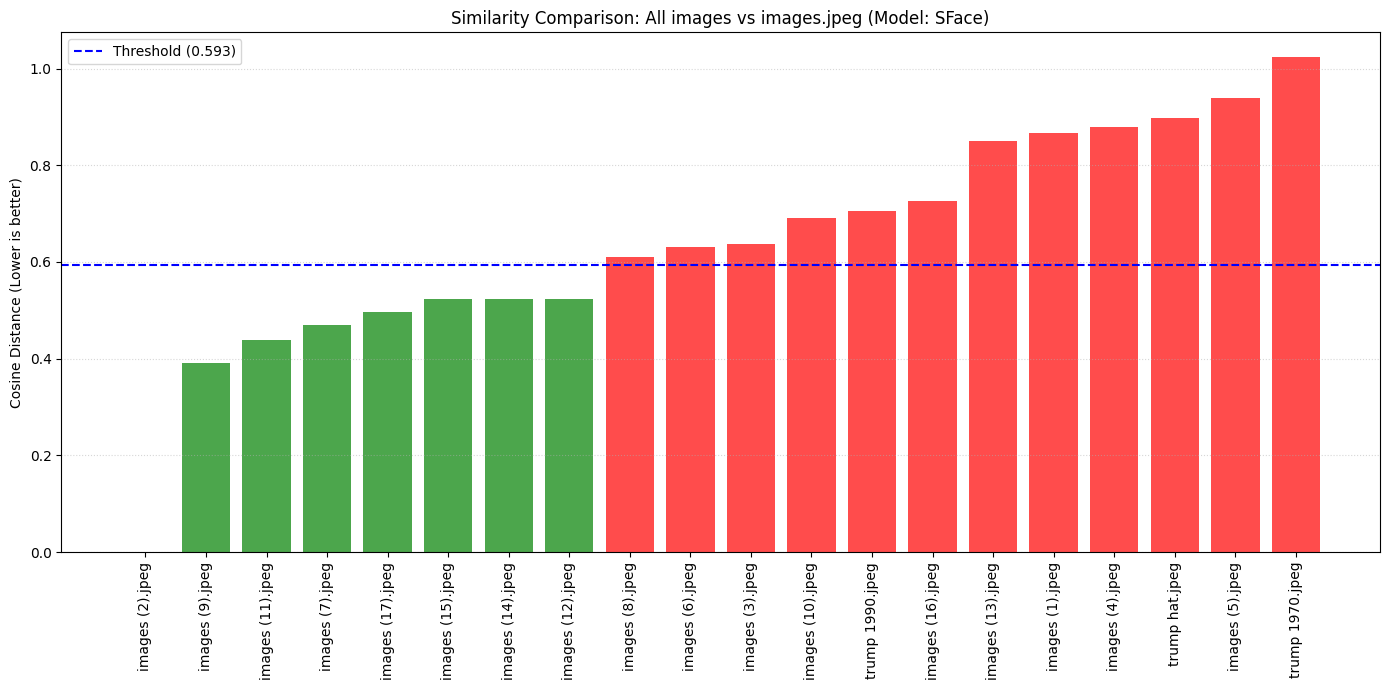

In [ ]:
# Visualization of Batch Comparison
plt.figure(figsize=(14, 7))

# Colors: Green for verified matches, Red for non-matches
colors = ['green' if v else 'red' for v in df_batch['Verified']]

plt.bar(df_batch['Filename'], df_batch['Distance'], color=colors, alpha=0.7)
plt.axhline(y=df_batch['Threshold'].iloc[0], color='blue', linestyle='--', label=f"Threshold ({df_batch['Threshold'].iloc[0]})")

plt.xticks(rotation=90)
plt.ylabel('Cosine Distance (Lower is better)')
plt.title(f'Similarity Comparison: All images vs {ref_img_name} (Model: SFace)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Re-evaluating with Facenet Model

Let's try another strong model, **Facenet**, to compare all images against our reference (`images.jpeg`). Facenet is well-regarded for its accuracy in face verification tasks. We will then visualize the results by displaying each target image with its verification status and metrics.

In [ ]:
import os
import pandas as pd
from deepface import DeepFace

# Using existing definitions from previous cells:
# ref_img_name = 'images.jpeg'
# ref_img_path = os.path.join(active_folders['Trump'], ref_img_name)
# all_imgs = [f for f in os.listdir(active_folders['Trump']) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and f != ref_img_name]

facenet_batch_results = []
chosen_model = "Facenet" # New model choice

print(f"Comparing all images in folder against reference: {os.path.basename(ref_img_path)} using {chosen_model}\n")

for img_name in all_imgs:
    target_path = os.path.join(active_folders['Trump'], img_name)
    try:
        res = DeepFace.verify(
            img1_path = ref_img_path,
            img2_path = target_path,
            model_name = chosen_model,
            detector_backend = "mtcnn",
            enforce_detection = False
        )
        facenet_batch_results.append({
            "Filename": img_name,
            "Distance": round(res["distance"], 4),
            "Verified": res["verified"],
            "Threshold": res["threshold"]
        })
    except Exception as e:
        print(f"Error processing {img_name} with {chosen_model}: {e}")

df_facenet_batch = pd.DataFrame(facenet_batch_results).sort_values(by="Distance")
display(df_facenet_batch)

Comparing all images in folder against reference: images.jpeg using Facenet



,Filename,Distance,Verified,Threshold
1,images (2).jpeg,-0.0000,True,0.4
9,images (10).jpeg,0.1589,True,0.4
6,images (7).jpeg,0.1827,True,0.4
17,images (17).jpeg,0.2112,True,0.4
10,images (11).jpeg,0.2209,True,0.4
11,images (12).jpeg,0.2271,True,0.4
0,images (1).jpeg,0.2480,True,0.4
16,images (16).jpeg,0.2614,True,0.4
2,images (3).jpeg,0.2812,True,0.4
15,images (15).jpeg,0.2958,True,0.4


### Comprehensive Model Evaluation Across All Datasets

Now, let's perform a comprehensive evaluation. We will iterate through each of your active folders ('Trump', 'Prophet lovy', 'Christie') and for each folder, we will run the verification process using *all* available facial recognition models. For each combination, we will display the verification results and individual image visualizations, just as we did previously.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace

def evaluate_and_plot_model(
    folder_name: str,
    folder_path: str,
    all_images_in_folder: list,
    model_name: str
) -> pd.DataFrame:
    """
    Performs facial verification for a given folder and model, then visualizes the results.
    Assumes the first image in `all_images_in_folder` is the reference.
    Returns a DataFrame of the verification results.
    """
    if not all_images_in_folder:
        print(f"Skipping {folder_name} for model {model_name}: No images found.")
        return pd.DataFrame()

    # Choose the first image as reference
    ref_img_name = all_images_in_folder[0]
    ref_img_path = os.path.join(folder_path, ref_img_name)

    # Get target images (all except the reference)
    target_imgs = [img for img in all_images_in_folder if img != ref_img_name]

    print(f"\n--- Evaluating '{folder_name}' with {model_name}. Reference: {ref_img_name} ---")

    batch_results = []
    for img_name in target_imgs:
        target_path = os.path.join(folder_path, img_name)
        try:
            res = DeepFace.verify(
                img1_path = ref_img_path,
                img2_path = target_path,
                model_name = model_name,
                detector_backend = "mtcnn",
                enforce_detection = False
            )
            batch_results.append({
                "Filename": img_name,
                "Distance": round(res["distance"], 4),
                "Verified": res["verified"],
                "Threshold": res["threshold"]
            })
        except Exception as e:
            print(f"Error processing {img_name} in {folder_name} with {model_name}: {e}")

    if not batch_results:
        print(f"No verification results for {folder_name} with {model_name}.")
        return pd.DataFrame()

    df_batch_results = pd.DataFrame(batch_results).sort_values(by="Distance")
    display(df_batch_results)

    # --- Visualization ---
    df_display = df_batch_results.sort_values(by=['Verified', 'Distance'], ascending=[False, True])

    # Display reference image
    plt.figure(figsize=(6, 6))
    img_ref = Image.open(ref_img_path)
    plt.imshow(img_ref)
    plt.title(f"Reference Image: {os.path.basename(ref_img_path)}", fontsize=14, color='blue')
    plt.axis('off')
    plt.show()

    # Display target images in a grid
    num_images = len(df_display)
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 4))
    axes = axes.flatten()

    plt.suptitle(
        f"'{folder_name}' Comparisons with {model_name} (Reference: {os.path.basename(ref_img_path)})",
        y=1.02, fontsize=16
    )

    for i, row in df_display.iterrows():
        target_img_name = row['Filename']
        target_path = os.path.join(folder_path, target_img_name)
        verified = row['Verified']
        distance = row['Distance']
        threshold = row['Threshold']

        img_target = Image.open(target_path)

        ax = axes[i]
        ax.imshow(img_target)
        title_color = 'green' if verified else 'red'
        ax.set_title(f"{target_img_name}\nVerified: {verified}\nDist: {distance:.3f} (Th: {threshold:.3f})", color=title_color, fontsize=9)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    return df_batch_results

In [ ]:
all_available_models = [
  "VGG-Face",
  "Facenet",
  "Facenet512",
  "OpenFace",
  "DeepFace",
  "DeepID",
  "ArcFace",
  "Dlib",
  "SFace",
  "GhostFaceNet",
]

total_verified_counts_per_model = {model: 0 for model in all_available_models}

# Loop through each active folder
for folder_name, folder_path in active_folders.items():
    print(f"\n### Processing Folder: {folder_name} ###")

    # Get all valid image files in the current folder
    all_images_in_folder = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    if not all_images_in_folder:
        print(f"No images found in {folder_name}. Skipping.")
        continue

    # Loop through each model for the current folder
    for model_name in all_available_models:
        df_results = evaluate_and_plot_model(folder_name, folder_path, all_images_in_folder, model_name)
        if not df_results.empty:
            verified_count = df_results['Verified'].sum()
            total_verified_counts_per_model[model_name] += verified_count

print("\n--- Overall Verification Summary ---")
print("Total Successful Verifications per Model:")
for model, count in sorted(total_verified_counts_per_model.items(), key=lambda item: item[1], reverse=True):
    print(f"- {model}: {count} successful verifications")

if total_verified_counts_per_model:
    best_model = max(total_verified_counts_per_model, key=total_verified_counts_per_model.get)
    highest_count = total_verified_counts_per_model[best_model]
    print(f"\nThe model with the highest number of successful verifications is: {best_model} with {highest_count} verifications.")
else:
    print("No verification data collected.")

## Exploring Other DeepFace Model Use Cases and Capabilities

Beyond basic verification, DeepFace models offer a range of functionalities. Let's outline some key capabilities and then explore them one by one:

1.  **Face Detection:** Identifying and localizing faces within an image.
2.  **Face Alignment:** Standardizing face orientation and size for better comparison.
3.  **Face Representation (Embeddings):** Generating numerical vectors that uniquely represent a face, used for similarity comparisons.
4.  **Face Recognition:** Identifying an individual from a database of known faces.
5.  **Facial Attribute Analysis:** Detecting attributes like age, gender, emotion, and race.

We can go through each of these capabilities. Please let me know which one you'd like to start with, or if you have a specific use case in mind!

### 5. Facial Attribute Analysis: Age, Gender, Emotion, and Race Detection

DeepFace can analyze faces to predict various attributes. We'll pick an image and use `DeepFace.analyze` to extract these features. This function returns a dictionary containing predictions for age, gender, emotion, and race.

In [ ]:
import os

# Re-verify folders and populate active_folders (ensuring paths are current)
folder_names = ["Trump", "Prophet lovy", "Christie"]
active_folders = {}
def find_path(name):
    for root, dirs, _ in os.walk('/content/drive/MyDrive'):
        for d in dirs:
            if d.lower() == name.lower():
                return os.path.join(root, d)
    return None

for name in folder_names:
    p = find_path(name)
    if p: active_folders[name] = p

print("active_folders populated:", active_folders)

active_folders populated: {'Trump': '/content/drive/MyDrive/Trump', 'Prophet lovy': '/content/drive/MyDrive/Prophet lovy', 'Christie': '/content/drive/MyDrive/Christie'}



--- Analyzing attributes for: images.jpeg from folder: Trump ---



Action: race: 100%|██████████| 4/4 [00:01<00:00,  2.28it/s]


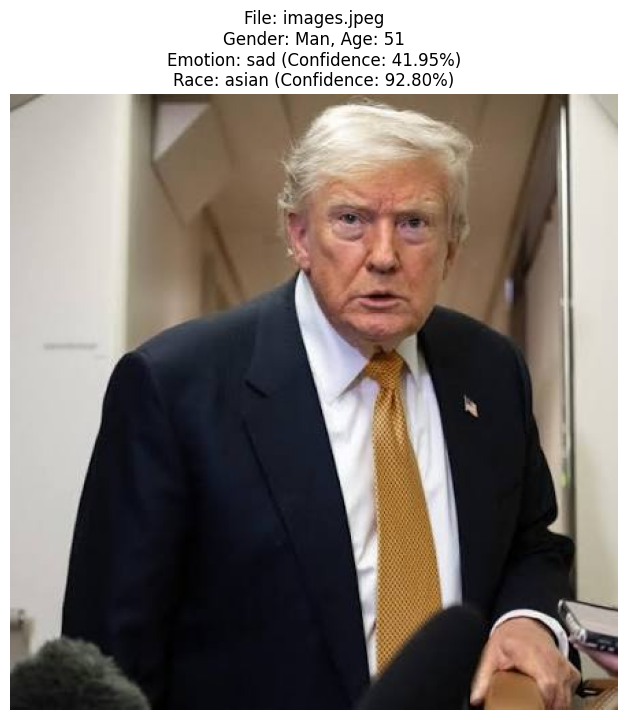

--- Detailed Analysis Results ---
Detected Face Area: {'x': 218, 'y': 37, 'w': 104, 'h': 138, 'left_eye': (295, 94), 'right_eye': (249, 92)}
Gender: Man
Age: 51
Emotion: sad (Confidence: 41.95%)
Race: asian (Confidence: 92.80%)

All Emotion Probabilities:
  angry: 36.16%
  disgust: 0.00%
  fear: 5.11%
  happy: 0.00%
  sad: 41.95%
  surprise: 0.00%
  neutral: 16.77%

All Race Probabilities:
  asian: 92.80%
  indian: 0.02%
  black: 0.00%
  white: 6.76%
  middle eastern: 0.06%
  latino hispanic: 0.36%


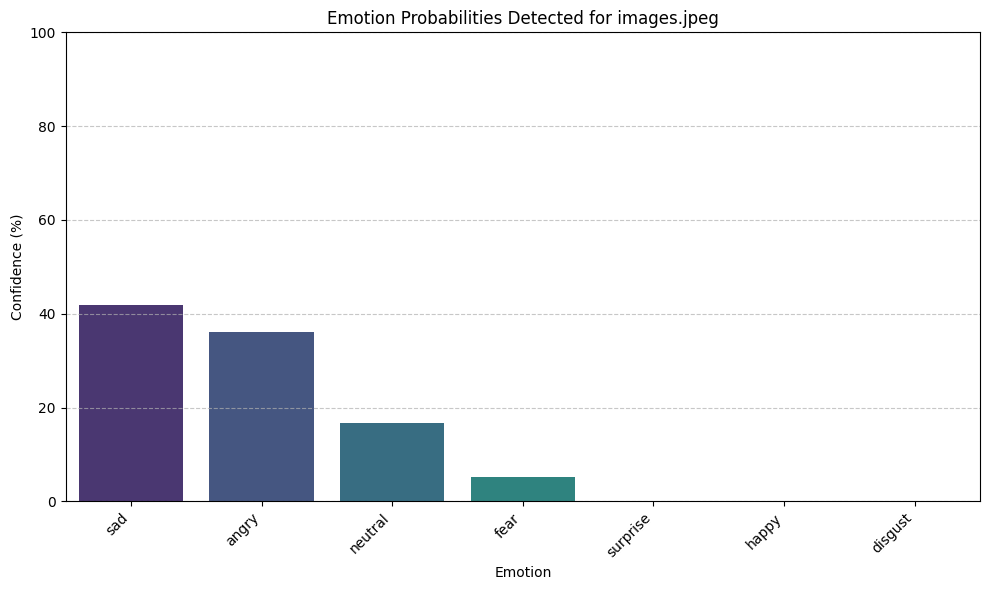


--- Analyzing attributes for: image1.jpeg from folder: Prophet lovy ---



Action: race: 100%|██████████| 4/4 [00:01<00:00,  2.34it/s]


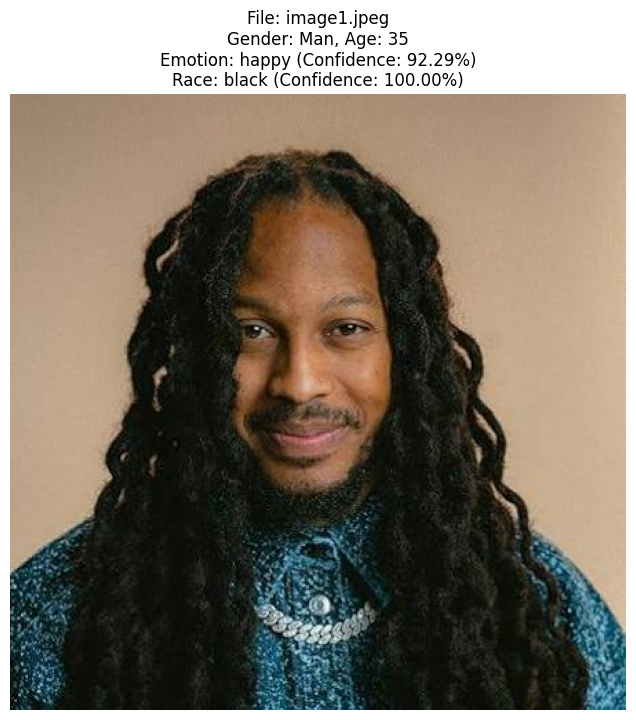

--- Detailed Analysis Results ---
Detected Face Area: {'x': 137, 'y': 95, 'w': 140, 'h': 193, 'left_eye': (243, 169), 'right_eye': (177, 170)}
Gender: Man
Age: 35
Emotion: happy (Confidence: 92.29%)
Race: black (Confidence: 100.00%)

All Emotion Probabilities:
  angry: 0.00%
  disgust: 0.00%
  fear: 0.00%
  happy: 92.29%
  sad: 0.00%
  surprise: 0.02%
  neutral: 7.69%

All Race Probabilities:
  asian: 0.00%
  indian: 0.00%
  black: 100.00%
  white: 0.00%
  middle eastern: 0.00%
  latino hispanic: 0.00%


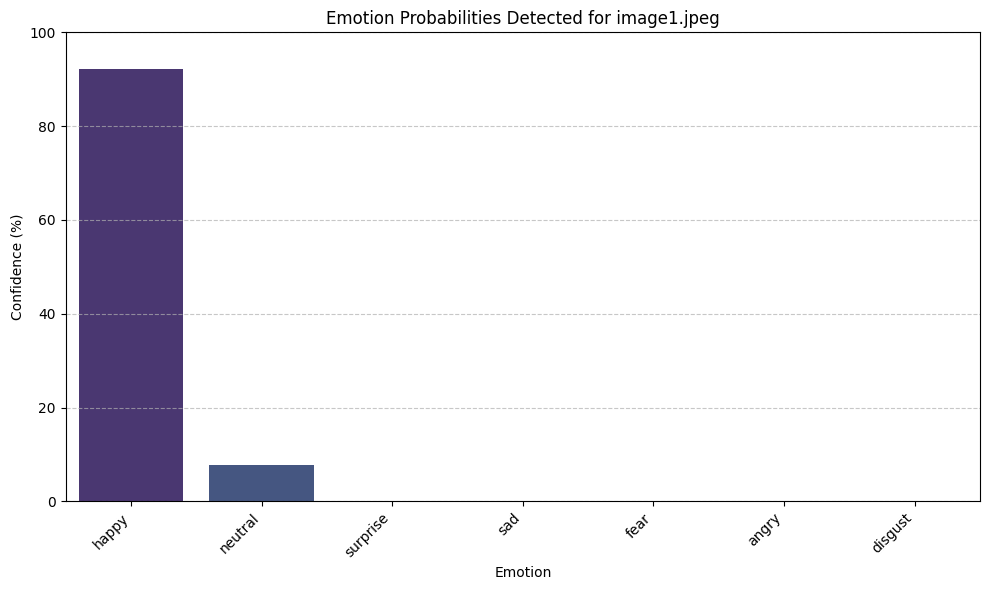


--- Analyzing attributes for: images.jpeg from folder: Christie ---



Action: race: 100%|██████████| 4/4 [00:02<00:00,  1.91it/s]


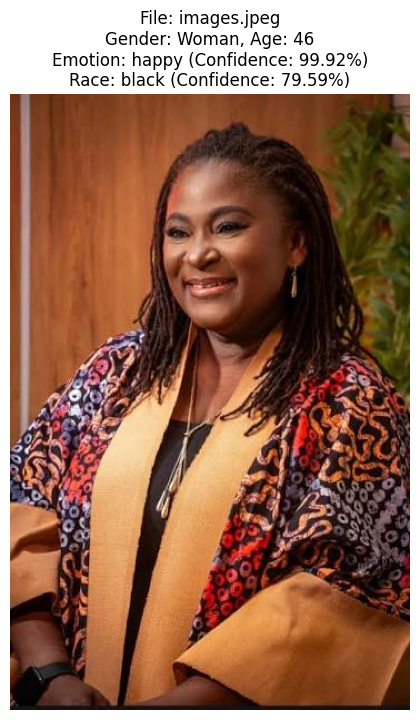

--- Detailed Analysis Results ---
Detected Face Area: {'x': 132, 'y': 65, 'w': 108, 'h': 141, 'left_eye': (195, 119), 'right_eye': (151, 123)}
Gender: Woman
Age: 46
Emotion: happy (Confidence: 99.92%)
Race: black (Confidence: 79.59%)

All Emotion Probabilities:
  angry: 0.00%
  disgust: 0.00%
  fear: 0.00%
  happy: 99.92%
  sad: 0.00%
  surprise: 0.00%
  neutral: 0.08%

All Race Probabilities:
  asian: 13.39%
  indian: 4.06%
  black: 79.59%
  white: 0.10%
  middle eastern: 0.06%
  latino hispanic: 2.81%


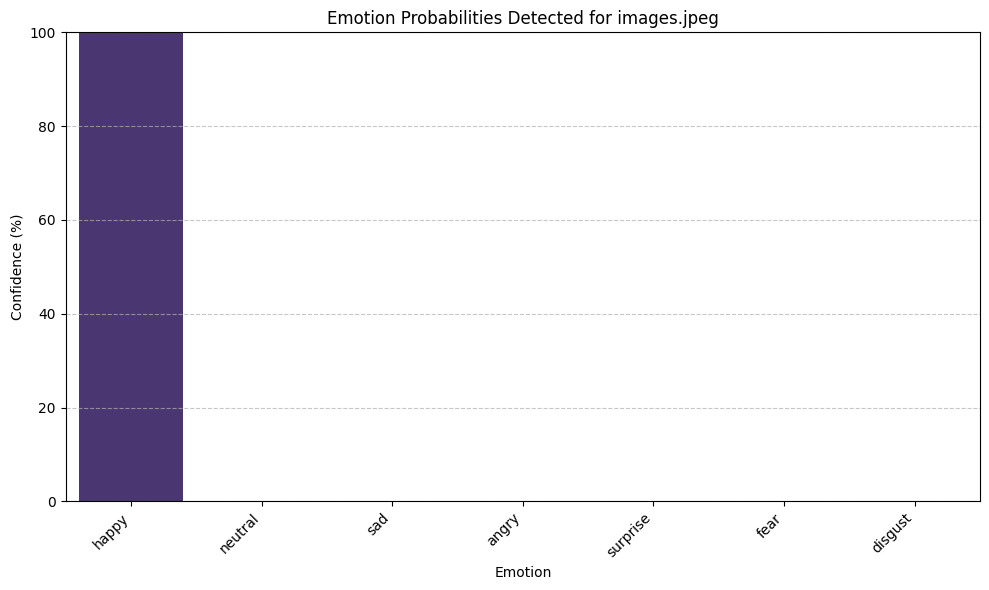

In [ ]:
!pip install deepface
import os
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace
import pandas as pd
import numpy as np

def display_analyzed_image(image_path, analysis_result):
    """
    Displays the original image with its detected attributes as the title.

    Args:
        image_path (str): Path to the image file.
        analysis_result (dict): Dictionary containing the analysis results for a single face.
    """
    plt.figure(figsize=(8, 8))
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')

    # Ensure gender is a string and handle numpy float32
    gender_info = analysis_result['gender']
    if isinstance(gender_info, dict):
        gender_str = analysis_result['dominant_gender']
    else:
        gender_str = str(gender_info)

    # Ensure race is a string and handle numpy float32
    race_info = analysis_result['race']
    if isinstance(race_info, dict):
        race_str = analysis_result['dominant_race']
    else:
        race_str = str(race_info)

    title_str = f"File: {os.path.basename(image_path)}\n"
    title_str += f"Gender: {gender_str}, Age: {analysis_result['age']}\n"
    title_str += f"Emotion: {analysis_result['dominant_emotion']} (Confidence: {analysis_result['emotion'][analysis_result['dominant_emotion']]:.2f}%)\n"
    title_str += f"Race: {race_str} (Confidence: {analysis_result['race'][analysis_result['dominant_race']]:.2f}%)"

    plt.title(title_str, fontsize=12)
    plt.show()

    # Print detailed analysis results to console as well
    print("--- Detailed Analysis Results ---")
    print(f"Detected Face Area: {analysis_result['region']}")
    print(f"Gender: {gender_str}")
    print(f"Age: {analysis_result['age']}")
    print(f"Emotion: {analysis_result['dominant_emotion']} (Confidence: {analysis_result['emotion'][analysis_result['dominant_emotion']]:.2f}%)")
    print(f"Race: {race_str} (Confidence: {analysis_result['race'][analysis_result['dominant_race']]:.2f}%)")

    print("\nAll Emotion Probabilities:")
    for emotion, confidence in analysis_result['emotion'].items():
        print(f"  {emotion}: {confidence:.2f}%")

    print("\nAll Race Probabilities:")
    for race, confidence in analysis_result['race'].items():
        print(f"  {race}: {confidence:.2f}%")

def plot_emotion_probabilities(analysis_result):
    """
    Plots a bar chart of emotion probabilities from DeepFace analysis results.
    """
    emotions = analysis_result['emotion']
    emotion_labels = list(emotions.keys())
    emotion_confidences = [emotions[label] for label in emotion_labels]

    df_emotions = pd.DataFrame({
        'Emotion': emotion_labels,
        'Confidence': emotion_confidences
    }).sort_values(by='Confidence', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Emotion', y='Confidence', data=df_emotions, palette='viridis')
    plt.title(f"Emotion Probabilities Detected for {os.path.basename(analysis_result['image_path'])}")
    plt.xlabel('Emotion')
    plt.ylabel('Confidence (%)')
    plt.ylim(0, 100) # Emotions are usually 0-100%
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# List of folders to analyze
target_folders = ['Trump', 'Prophet lovy', 'Christie']

for folder_name in target_folders:
    if folder_name in active_folders and os.listdir(active_folders[folder_name]):
        folder_path = active_folders[folder_name]
        # Select the first image in the folder for analysis
        image_to_analyze_path = os.path.join(folder_path, os.listdir(folder_path)[0])

        print(f"\n--- Analyzing attributes for: {os.path.basename(image_to_analyze_path)} from folder: {folder_name} ---\n")

        try:
            # Perform facial attribute analysis
            analysis_results = DeepFace.analyze(
                img_path=image_to_analyze_path,
                actions=['age', 'gender', 'emotion', 'race'],
                detector_backend='mtcnn', # Using mtcnn for robust detection
                enforce_detection=False
            )

            # DeepFace.analyze returns a list of dictionaries, one for each detected face.
            # We'll take the first detected face for simplicity.
            if analysis_results:
                first_face_result = analysis_results[0]
                first_face_result['image_path'] = image_to_analyze_path # Add image path for plotting title
                display_analyzed_image(image_to_analyze_path, first_face_result)
                plot_emotion_probabilities(first_face_result)
            else:
                print(f"No face detected in the image: {os.path.basename(image_to_analyze_path)}.")

        except Exception as e:
            print(f"Error during facial attribute analysis for {os.path.basename(image_to_analyze_path)}: {e}")
    else:
        print(f"Could not find folder '{folder_name}' or it contains no images for analysis.")


### 1. Face Detection: Identifying and Localizing Faces

DeepFace can detect faces within an image and provide their bounding box coordinates. We'll use the `DeepFace.extract_faces` function to demonstrate this, which also returns aligned faces if successful.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os
from deepface import DeepFace

# Loop through each active folder
for folder_name, folder_path in active_folders.items():
    print(f"\n--- Processing Folder: {folder_name} for Face Detection ---")

    # Get all valid image files in the current folder
    all_images_in_folder = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    if not all_images_in_folder:
        print(f"No images found in {folder_name}. Skipping.")
        continue

    for image_name in all_images_in_folder:
        image_for_detection_path = os.path.join(folder_path, image_name)

        print(f"\nPerforming face detection on: {os.path.basename(image_for_detection_path)}\n")

        try:
            # Detect faces using DeepFace.extract_faces
            # We can specify a detector_backend like 'opencv', 'retinaface', 'mtcnn', 'ssd', 'dlib', 'mediapipe', 'yolov8', 'pixellib', 'centerface'
            # retinaface is known for high accuracy.
            detected_faces = DeepFace.extract_faces(
                img_path=image_for_detection_path,
                detector_backend='retinaface', # Changed to retinaface for robust detection
                enforce_detection=False # Set to True if you want to raise error when no face is found
            )

            if detected_faces:
                print(f"Found {len(detected_faces)} face(s) in the image.\n")

                # Load the original image to draw bounding boxes
                original_image = Image.open(image_for_detection_path).convert("RGB")
                draw = ImageDraw.Draw(original_image)

                plt.figure(figsize=(10, 10))
                plt.imshow(original_image)
                plt.axis('off')
                plt.title(f"Face Detection in {os.path.basename(image_for_detection_path)}")

                for i, face in enumerate(detected_faces):
                    x, y, w, h = face['facial_area']['x'], face['facial_area']['y'], face['facial_area']['w'], face['facial_area']['h']
                    # Draw rectangle for the bounding box
                    draw.rectangle([(x, y), (x + w, y + h)], outline="red", width=3)
                    # Annotate the face number
                    plt.text(x, y - 10, f"Face {i+1}", color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

                    print(f"Face {i+1} - Bounding Box (x, y, w, h): ({x}, {y}, {w}, {h})")
                    print(f"Face {i+1} - Confidence: {face['confidence']:.2f}")
                    # You can also access face['img'] for the detected and aligned face image

                plt.imshow(original_image)
                plt.show()

            else:
                print(f"No faces detected in {os.path.basename(image_for_detection_path)}.")

        except Exception as e:
            print(f"Error during face detection for {os.path.basename(image_for_detection_path)}: {e}")

else:
    print("Could not find any images in active folders for face detection.")

Performing face alignment demonstration on: images.jpeg

Found 1 face(s) in the image. Displaying aligned faces.



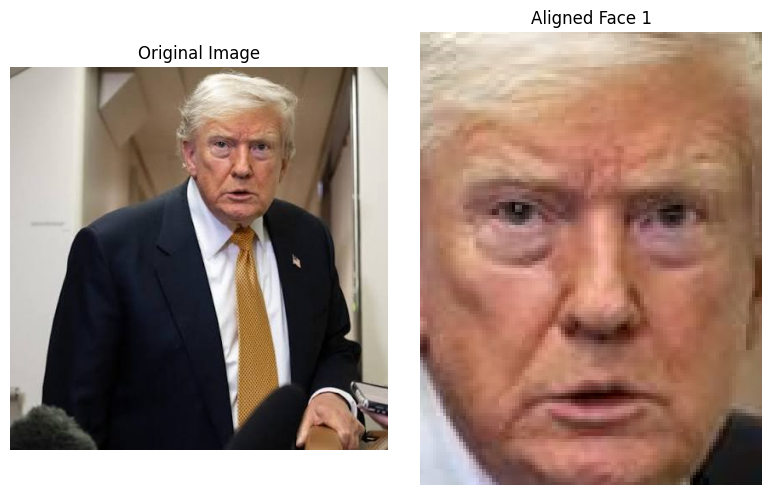

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
from deepface import DeepFace

# Choose an image from the 'Trump' folder for demonstration
# We'll use the first image available in the folder
if 'Trump' in active_folders and os.listdir(active_folders['Trump']):
    image_for_alignment_path = os.path.join(active_folders['Trump'], os.listdir(active_folders['Trump'])[0])

    print(f"Performing face alignment demonstration on: {os.path.basename(image_for_alignment_path)}\n")

    try:
        # DeepFace.extract_faces returns a list of dictionaries, each containing:
        # 'face': the aligned face image (numpy array)
        # 'facial_area': bounding box and landmarks
        # 'confidence': confidence score of detection
        extracted_faces = DeepFace.extract_faces(
            img_path=image_for_alignment_path,
            detector_backend='mtcnn', # Using mtcnn for robust detection
            enforce_detection=False # Set to False to prevent errors if no face is found
        )

        if extracted_faces:
            print(f"Found {len(extracted_faces)} face(s) in the image. Displaying aligned faces.\n")

            num_faces = len(extracted_faces)
            fig, axes = plt.subplots(1, num_faces + 1, figsize=(4 * (num_faces + 1), 5)) # +1 for original image

            # Display original image
            original_image = Image.open(image_for_alignment_path)
            axes[0].imshow(original_image)
            axes[0].set_title("Original Image")
            axes[0].axis('off')

            # Display each aligned face
            for i, face_data in enumerate(extracted_faces):
                aligned_face = face_data['face'] # This is the aligned face numpy array
                axes[i + 1].imshow(aligned_face)
                axes[i + 1].set_title(f"Aligned Face {i+1}")
                axes[i + 1].axis('off')

            plt.tight_layout()
            plt.show()
        else:
            print(f"No faces detected in {os.path.basename(image_for_alignment_path)}. Cannot perform alignment.")

    except Exception as e:
        print(f"Error during face alignment for {os.path.basename(image_for_alignment_path)}: {e}")

else:
    print("Could not find any images in the 'Trump' folder for face alignment demonstration.")

### 3. Face Representation (Embeddings): Converting Faces to Numerical Vectors

Face embeddings are numerical representations of faces in a high-dimensional space. The distance between these vectors can be used to determine the similarity between two faces. `DeepFace.represent` extracts these embeddings.

In [ ]:
import os
import numpy as np
from deepface import DeepFace

# Select two images from the 'Trump' folder for embedding generation
# Let's use the first two available images if there are enough
trump_images = [f for f in os.listdir(active_folders['Trump']) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(trump_images) >= 2:
    img_path1 = os.path.join(active_folders['Trump'], trump_images[0])
    img_path2 = os.path.join(active_folders['Trump'], trump_images[1])

    print(f"Generating embeddings for:\n1. {os.path.basename(img_path1)}\n2. {os.path.basename(img_path2)}\n")

    try:
        # Generate embeddings using DeepFace.represent
        # You can specify different models for generating embeddings
        embedding1_objs = DeepFace.represent(
            img_path=img_path1,
            model_name="Facenet", # Using Facenet for embeddings
            detector_backend='mtcnn', # Using mtcnn for face detection prior to embedding
            enforce_detection=False
        )
        embedding2_objs = DeepFace.represent(
            img_path=img_path2,
            model_name="Facenet",
            detector_backend='mtcnn',
            enforce_detection=False
        )

        # DeepFace.represent returns a list of dictionaries, one for each detected face.
        # We take the first face's embedding for simplicity.
        if embedding1_objs and embedding2_objs:
            embedding1 = embedding1_objs[0]["embedding"]
            embedding2 = embedding2_objs[0]["embedding"]

            print(f"Embedding for {os.path.basename(img_path1)} (first 5 elements): {embedding1[:5]}\n")
            print(f"Embedding for {os.path.basename(img_path2)} (first 5 elements): {embedding2[:5]}\n")

            # Calculate Cosine Similarity
            # Cosine Similarity = (A . B) / (||A|| * ||B||)
            cosine_similarity = np.dot(embedding1, embedding2) / (np.linalg.norm(embedding1) * np.linalg.norm(embedding2))
            cosine_distance = 1 - cosine_similarity

            print(f"Cosine Similarity between the two embeddings: {cosine_similarity:.4f}")
            print(f"Cosine Distance between the two embeddings: {cosine_distance:.4f}")

            # For Facenet, a common threshold for 'verified' is around 0.40 for cosine distance
            # (meaning similarity around 0.60)
            if cosine_distance < 0.40: # This threshold can vary by model and dataset
                print("These faces are likely of the same person (based on Facenet's typical threshold).")
            else:
                print("These faces are likely of different persons (based on Facenet's typical threshold).")

        else:
            print("Could not extract embeddings from one or both images. No faces detected.")

    except Exception as e:
        print(f"Error during embedding generation or comparison: {e}")

else:
    print("Not enough images found in the 'Trump' folder to demonstrate face embeddings. Please ensure there are at least two images.")

Generating embeddings for:
1. images.jpeg
2. images (1).jpeg



Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5


26-07-13 10:01:19 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


100%|██████████| 92.2M/92.2M [00:00<00:00, 240MB/s]


Embedding for images.jpeg (first 5 elements): [-1.0933573246002197, 0.31691834330558777, -0.1728288233280182, 0.8935953378677368, 1.2288137674331665]

Embedding for images (1).jpeg (first 5 elements): [0.9119147062301636, 0.5181232690811157, -2.2512431144714355, 1.1528035402297974, 0.6207509636878967]

Cosine Similarity between the two embeddings: 0.7519
Cosine Distance between the two embeddings: 0.2481
These faces are likely of the same person (based on Facenet's typical threshold).


### 4. Face Recognition: Identifying Individuals from a Database

Face recognition involves identifying an individual by comparing a target face with a database of known faces. `DeepFace.find` can be used to perform this task.

In [ ]:
import os
import pandas as pd
from deepface import DeepFace

# Define the target image (the face we want to identify)
# Let's use an image from the 'Prophet lovy' folder
if 'Prophet lovy' in active_folders and os.listdir(active_folders['Prophet lovy']):
    target_image_path = os.path.join(active_folders['Prophet lovy'], os.listdir(active_folders['Prophet lovy'])[0])
else:
    target_image_path = None
    print("Could not find an image in 'Prophet lovy' folder for face recognition.")

# Define the database folder (where we search for a match)
# Let's use the 'Trump' folder as our database
if 'Trump' in active_folders:
    db_path = active_folders['Trump']
else:
    db_path = None
    print("Could not find 'Trump' folder for face recognition database.")

if target_image_path and db_path:
    print(f"Performing face recognition:")
    print(f"  Target Image: {os.path.basename(target_image_path)}")
    print(f"  Database Folder: {db_path}\n")

    try:
        # Use DeepFace.find to search for the target face in the database
        # model_name: The face recognition model to use (e.g., VGG-Face, Facenet, ArcFace)
        # distance_metric: The metric to compare embeddings (e.g., cosine, euclidian)
        # enforce_detection: Set to False to proceed even if no face is detected in an image
        found_faces = DeepFace.find(
            img_path = target_image_path,
            db_path = db_path,
            model_name = "VGG-Face", # Using VGG-Face for recognition
            distance_metric = "cosine",
            detector_backend = "mtcnn",
            enforce_detection = False
        )

        # DeepFace.find returns a list of dataframes (one for each detected face in the target image)
        # We'll display the first dataframe if it exists.
        if found_faces and not found_faces[0].empty:
            print("Matches found in the database:")
            display(found_faces[0])
        else:
            print("No matches found for the target image in the database.")

    except Exception as e:
        print(f"Error during face recognition: {e}")
else:
    print("Cannot proceed with face recognition due to missing target image or database path.")

Performing face recognition:
  Target Image: image1.jpeg
  Database Folder: /content/drive/MyDrive/Trump

26-07-13 10:02:34 - Found 21 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/21 [00:00<?, ?it/s]Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5


26-07-13 10:02:38 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...



  0%|          | 0.00/580M [00:00<?, ?B/s]
  3%|▎         | 15.2M/580M [00:00<00:03, 152MB/s]
  9%|▊         | 49.8M/580M [00:00<00:02, 264MB/s]
 14%|█▍        | 82.3M/580M [00:00<00:01, 291MB/s]
 19%|█▉        | 112M/580M [00:00<00:01, 273MB/s] 
 24%|██▍       | 139M/580M [00:00<00:01, 269MB/s]
 29%|██▊       | 167M/580M [00:00<00:01, 267MB/s]
 34%|███▍      | 198M/580M [00:00<00:01, 282MB/s]
 40%|███▉      | 231M/580M [00:00<00:01, 295MB/s]
 46%|████▌     | 266M/580M [00:00<00:01, 311MB/s]
 52%|█████▏    | 299M/580M [00:01<00:00, 318MB/s]
 57%|█████▋    | 331M/580M [00:01<00:00, 305MB/s]
 62%|██████▏   | 362M/580M [00:01<00:00, 269MB/s]
 67%|██████▋   | 390M/580M [00:01<00:00, 221MB/s]
 71%|███████▏  | 414M/580M [00:01<00:00, 199MB/s]
 75%|███████▌  | 436M/580M [00:01<00:00, 189MB/s]
 79%|███████▊  | 456M/580M [00:01<00:00, 177MB/s]
 82%|████████▏ | 476M/580M [00:02<00:00, 182MB/s]
 85%|████████▌ | 494M/580M [00:02<00:00, 183MB/s]
 88%|████████▊ | 513M/580M [00:02<00:00, 166MB/s]
 9

26-07-13 10:03:29 - There are now 41 representations in ds_model_vggface_detector_mtcnn_aligned_normalization_base_expand_0.pkl
26-07-13 10:03:29 - Searching /content/drive/MyDrive/Prophet lovy/image1.jpeg in 41 length datastore
26-07-13 10:03:30 - find function duration 56.90416383743286 seconds
No matches found for the target image in the database.


**Initial Face Verification** (Trump vs. Prophet lovy): We started with VGG-Face and then compared it with Facenet, ArcFace, and SFace.

**Same Person Verification **(Trump images): We used VGG-Face, Facenet, and ArcFace.

**Age Gap Comparison** (Trump 1970 vs. 1990): We tested VGG-Face, Facenet, ArcFace, and specifically SFace.
1970 vs. Recent Comparison (Trump): We used SFace.

**Batch Comparison **(Trump images vs. reference): Initially, we used SFace, and then re-evaluated with Facenet.

**Comprehensive Model Evaluation:** We systematically evaluated all available models: VGG-Face, Facenet, Facenet512, OpenFace, DeepFace, DeepID, ArcFace, Dlib, SFace, and GhostFaceNet.

**Facial Attribute Analysis**(Age, Gender, Emotion, Race): DeepFace automatically selects the appropriate internal models for each action (age, gender, emotion, race). No specific single model is explicitly chosen by the user for this function.

**Face Detection:** For most of our explorations, we used the MTCNN detector backend. In the most recent attempt, you requested to experiment with RetinaFace for potentially better accuracy.

**Face Alignment:** We used the MTCNN detector backend within DeepFace.extract_faces.

**Face Representation **(Embeddings): We generated embeddings using the Facenet model.

**Face Recognition** (DeepFace.find): We used the VGG-Face model to search for a target image in a database.


